# Analyse Descriptive et Exploratoire — CityCompare
**Angers vs Colombes**

## 0 — Imports et chargement des données

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA = 'data/processed/'
COLORS = ['#2196F3', '#FF9800']  # Angers = bleu, Colombes = orange

df_gen   = pd.read_excel(DATA + 'donnees_generale_filtrer.xlsx')
df_log   = pd.read_excel(DATA + 'logement_filtrer.xlsx')
df_meteo = pd.read_excel(DATA + 'donnees_open_meteo.xlsx')
df_edu   = pd.read_excel(DATA + 'education_filtrer.xlsx')
df_cult  = pd.read_excel(DATA + 'culture_filtrer.xlsx')
df_sport = pd.read_excel(DATA + 'sport_filtrer.xlsx')

df_meteo['datetime'] = pd.to_datetime(df_meteo['datetime'])

# Emploi : fusion des deux fichiers
emp_angers   = pd.read_csv(DATA + 'emploi_entreprise_angers.csv', sep=';', encoding='utf-8')
emp_colombes = pd.read_csv(DATA + 'emplois_entreprise_colombes.csv', sep=';', encoding='utf-8')
emp_angers['ville']   = 'Angers'
emp_colombes['ville'] = 'Colombes'
df_emp = pd.concat([emp_angers, emp_colombes], ignore_index=True)

print('Données chargées :')
for nom, df in [('Générale', df_gen), ('Logement', df_log), ('Météo', df_meteo),
                ('Éducation', df_edu), ('Culture', df_cult), ('Sport', df_sport), ('Emploi', df_emp)]:
    print(f'  {nom:12s}: {df.shape[0]} lignes x {df.shape[1]} colonnes')

Données chargées :
  Générale    : 2 lignes x 49 colonnes
  Logement    : 2 lignes x 16 colonnes
  Météo       : 17568 lignes x 7 colonnes
  Éducation   : 206 lignes x 37 colonnes
  Culture     : 204 lignes x 54 colonnes
  Sport       : 708 lignes x 113 colonnes
  Emploi      : 6217 lignes x 58 colonnes


---
## 1 — Données générales

In [ ]:
cols = ['nom_standard', 'population', 'superficie_km2', 'densite',
        'dep_nom', 'reg_nom', 'altitude_moyenne', 'score']

df_gen[cols].set_index('nom_standard')

,population,superficie_km2,densite,dep_nom,reg_nom,altitude_moyenne,score
nom_standard,,,,,,,
Angers,157175,44,3546,Maine-et-Loire,Pays de la Loire,32,82.2/100
Colombes,88870,8,11423,Hauts-de-Seine,Île-de-France,33,53.6/100


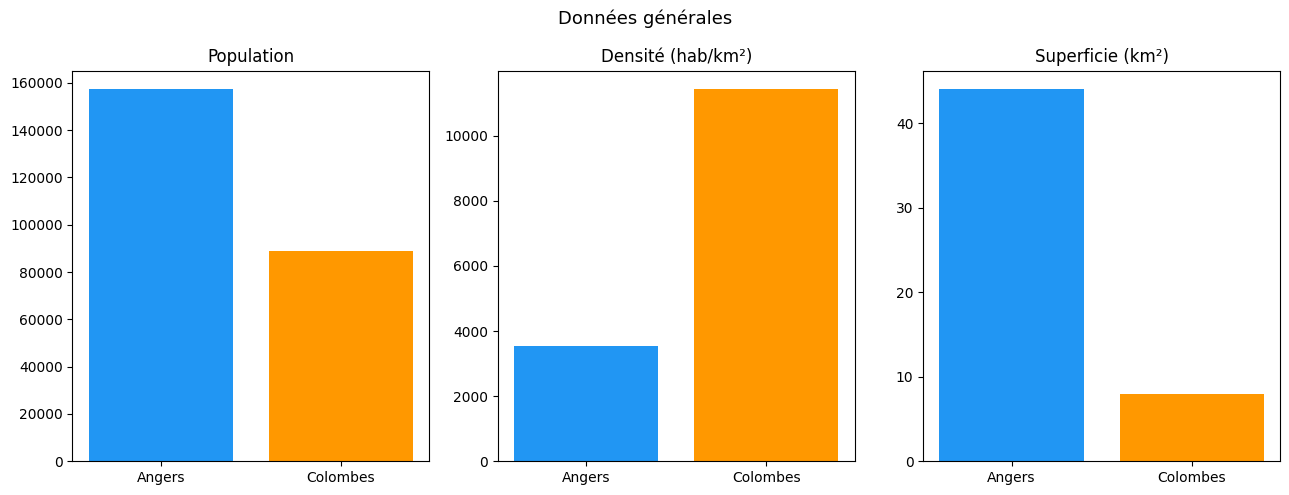

In [ ]:
villes = df_gen['nom_standard'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, col, titre in zip(axes,
    ['population', 'densite', 'superficie_km2'],
    ['Population', 'Densité (hab/km²)', 'Superficie (km²)']):
    ax.bar(villes, df_gen[col], color=COLORS)
    ax.set_title(titre)

plt.suptitle('Données générales', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2 — Logement

In [ ]:
df_log.set_index('libelle_geo').drop(columns=['code_geo', 'code_parent', 'echelle_geo'])

,nb_ventes_whole_appartement,moy_prix_m2_whole_appartement,med_prix_m2_whole_appartement,nb_ventes_whole_maison,moy_prix_m2_whole_maison,med_prix_m2_whole_maison,nb_ventes_whole_apt_maison,moy_prix_m2_whole_apt_maison,med_prix_m2_whole_apt_maison,nb_ventes_whole_local,moy_prix_m2_whole_local,med_prix_m2_whole_local
libelle_geo,,,,,,,,,,,,
Angers,8855,3168,3084,2953,3413,3214,11808,3230,3122,774,19239,2606
Colombes,4213,5372,5346,1440,7963,7584,5653,6032,5675,169,4789,3667


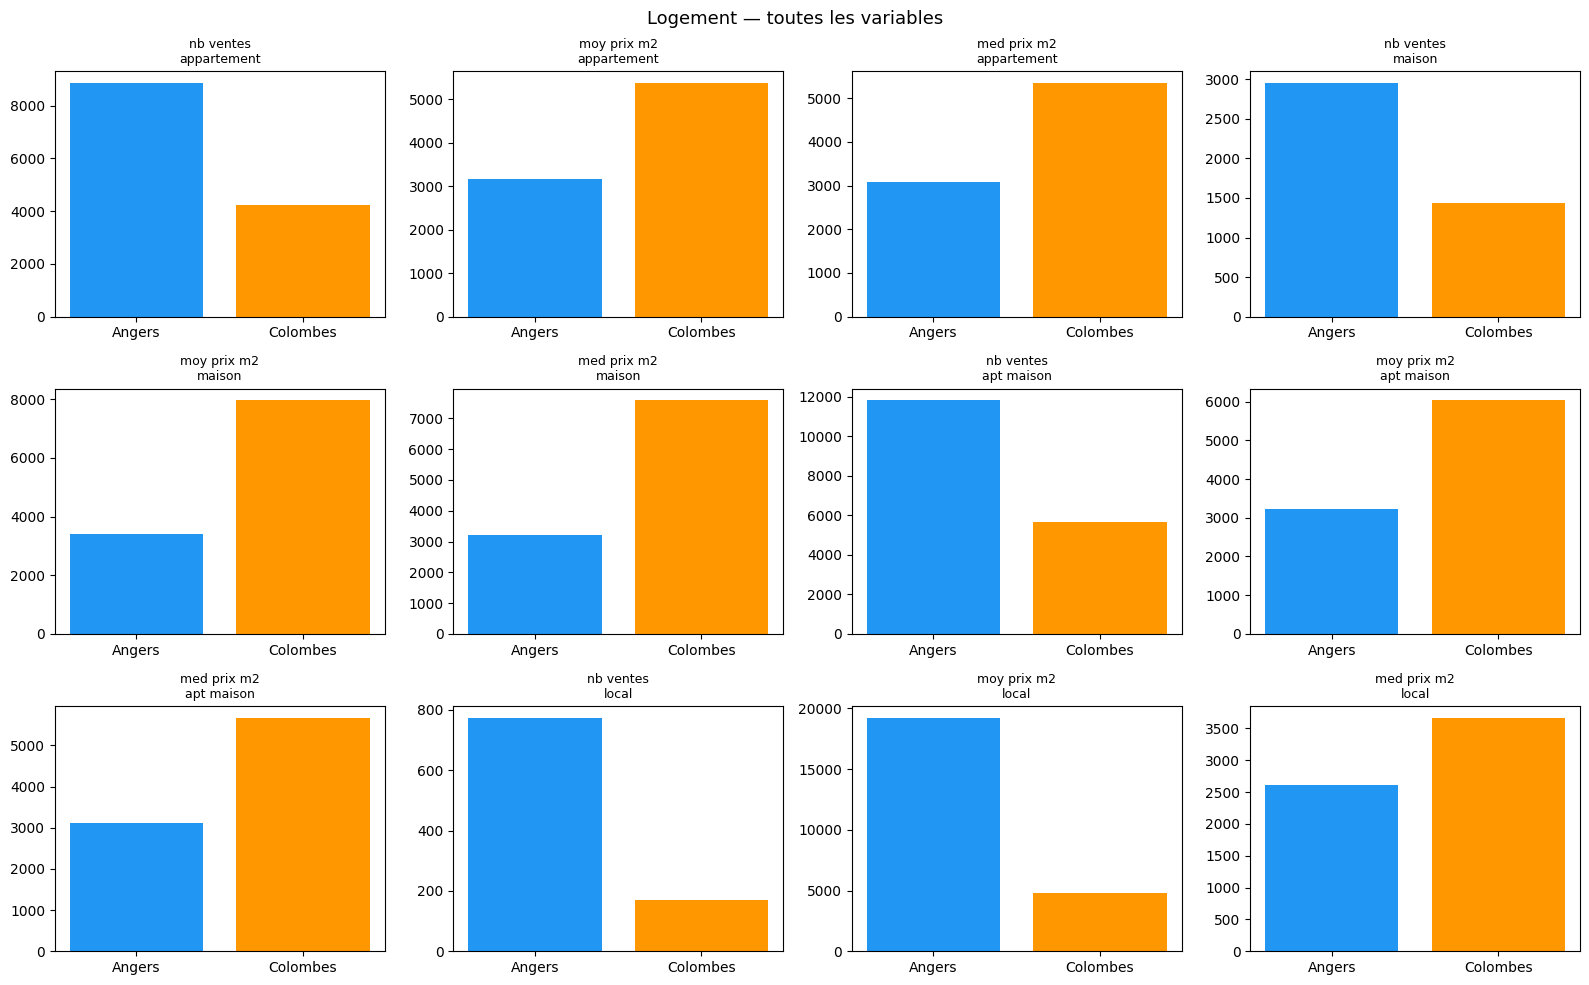

In [ ]:
variables = [
    'nb_ventes_whole_appartement',
    'moy_prix_m2_whole_appartement',
    'med_prix_m2_whole_appartement',
    'nb_ventes_whole_maison',
    'moy_prix_m2_whole_maison',
    'med_prix_m2_whole_maison',
    'nb_ventes_whole_apt_maison',
    'moy_prix_m2_whole_apt_maison',
    'med_prix_m2_whole_apt_maison',
    'nb_ventes_whole_local',
    'moy_prix_m2_whole_local',
    'med_prix_m2_whole_local',
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, variables):
    vals = df_log[col].tolist()
    ax.bar(df_log['libelle_geo'], vals, color=COLORS)
    ax.set_title(col.replace('_whole_', '\n').replace('_', ' '), fontsize=9)

plt.suptitle('Logement — toutes les variables', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3 — Météo

In [ ]:
df_meteo.groupby('ville')[['temperature_2m', 'relativehumidity_2m', 'wind_speed_10m', 'precipitation']].describe().round(2)

temperature_2m                                            \
                  count   mean   std  min  25%    50%   75%   max   
ville                                                               
Angers           8784.0  13.82  6.83 -5.3  9.3  13.10  18.0  36.9   
Colombes         8784.0  13.30  6.99 -6.3  8.6  12.65  17.7  38.7   

         relativehumidity_2m         ... wind_speed_10m       precipitation  \
                       count   mean  ...            75%   max         count   
ville                                ...                                      
Angers                8784.0  75.94  ...           15.7  40.9        8784.0   
Colombes              8784.0  74.73  ...           13.1  33.6        8784.0   

                                               
          mean   std  min  25%  50%  75%  max  
ville                                          
Angers    0.08  0.35  0.0  0.0  0.0  0.0  6.4  
Colombes  0.09  0.39  0.0  0.0  0.0  0.0  8.0  

[2 rows x 32 columns]

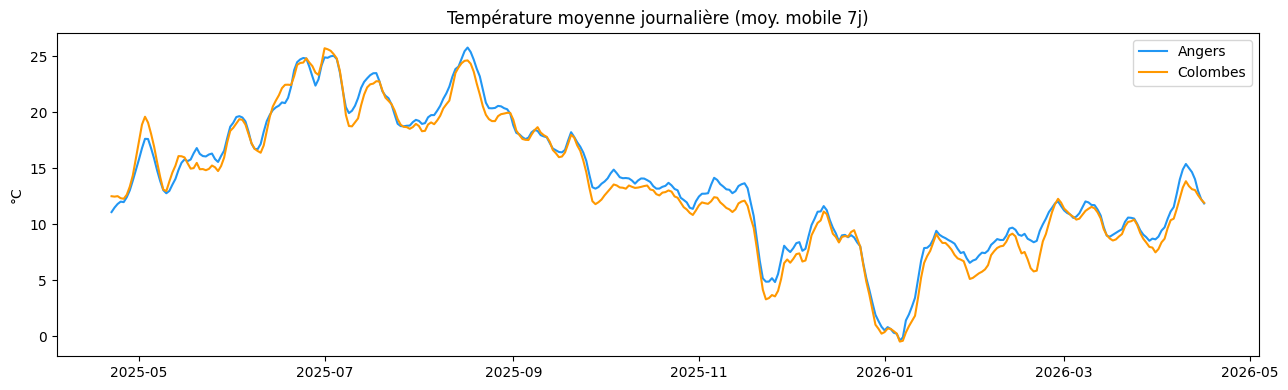

In [ ]:
# Série temporelle de température (moyenne journalière)
df_meteo['date'] = df_meteo['datetime'].dt.date
df_daily = df_meteo.groupby(['ville', 'date']).agg(
    temp_moy=('temperature_2m', 'mean'),
    precipitation=('precipitation', 'sum')
).reset_index()
df_daily['date'] = pd.to_datetime(df_daily['date'])

fig, ax = plt.subplots(figsize=(13, 4))
for ville, color in zip(['Angers', 'Colombes'], COLORS):
    sub = df_daily[df_daily['ville'] == ville].sort_values('date')
    ax.plot(sub['date'], sub['temp_moy'].rolling(7).mean(), label=ville, color=color)
ax.set_title('Température moyenne journalière (moy. mobile 7j)')
ax.set_ylabel('°C')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\manoh\AppData\Local\Temp\ipykernel_9736\4252446570.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=mois_labels, patch_artist=True,
C:\Users\manoh\AppData\Local\Temp\ipykernel_9736\4252446570.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=mois_labels, patch_artist=True,


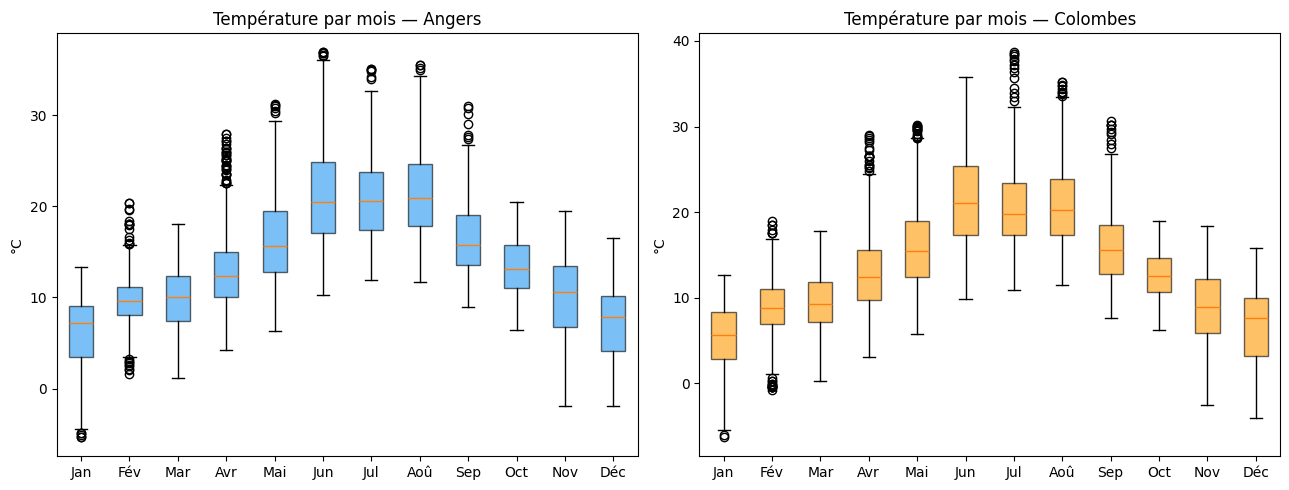

In [ ]:
# Boxplot mensuel des températures
df_meteo['mois'] = df_meteo['datetime'].dt.month
mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ville, color in zip(axes, ['Angers', 'Colombes'], COLORS):
    sub = df_meteo[df_meteo['ville'] == ville]
    data = [sub[sub['mois'] == m]['temperature_2m'].values for m in range(1, 13)]
    ax.boxplot(data, labels=mois_labels, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(f'Température par mois — {ville}')
    ax.set_ylabel('°C')
plt.tight_layout()
plt.show()

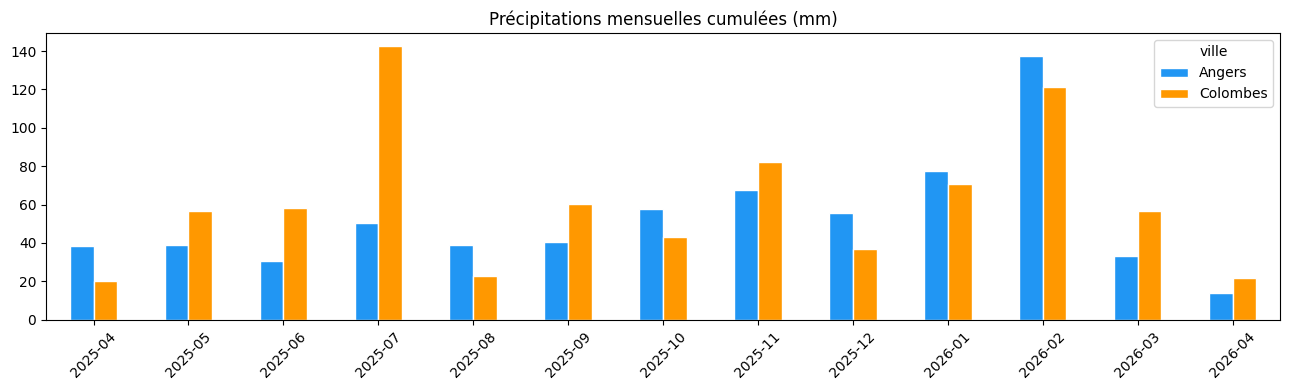

In [ ]:
# Précipitations mensuelles cumulées
df_daily['mois'] = df_daily['date'].dt.strftime('%Y-%m')
precip = df_daily.groupby(['ville', 'mois'])['precipitation'].sum().reset_index()
precip_pivot = precip.pivot(index='mois', columns='ville', values='precipitation').fillna(0)

precip_pivot.plot(kind='bar', color=COLORS, figsize=(13, 4), edgecolor='white')
plt.title('Précipitations mensuelles cumulées (mm)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\manoh\AppData\Local\Temp\ipykernel_9736\3263049392.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_meteo, x='ville', y=col, palette={'Angers': '#2196F3', 'Colombes': '#FF9800'}, ax=ax)
C:\Users\manoh\AppData\Local\Temp\ipykernel_9736\3263049392.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_meteo, x='ville', y=col, palette={'Angers': '#2196F3', 'Colombes': '#FF9800'}, ax=ax)


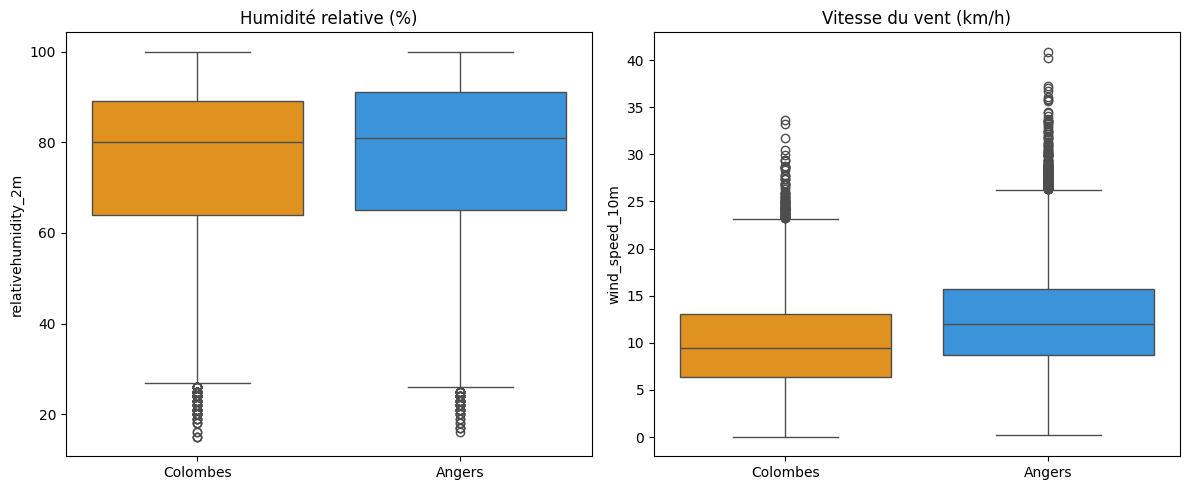

In [ ]:
# Distribution humidité et vent
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, titre in zip(axes,
    ['relativehumidity_2m', 'wind_speed_10m'],
    ['Humidité relative (%)', 'Vitesse du vent (km/h)']):
    sns.boxplot(data=df_meteo, x='ville', y=col, palette={'Angers': '#2196F3', 'Colombes': '#FF9800'}, ax=ax)
    ax.set_title(titre)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

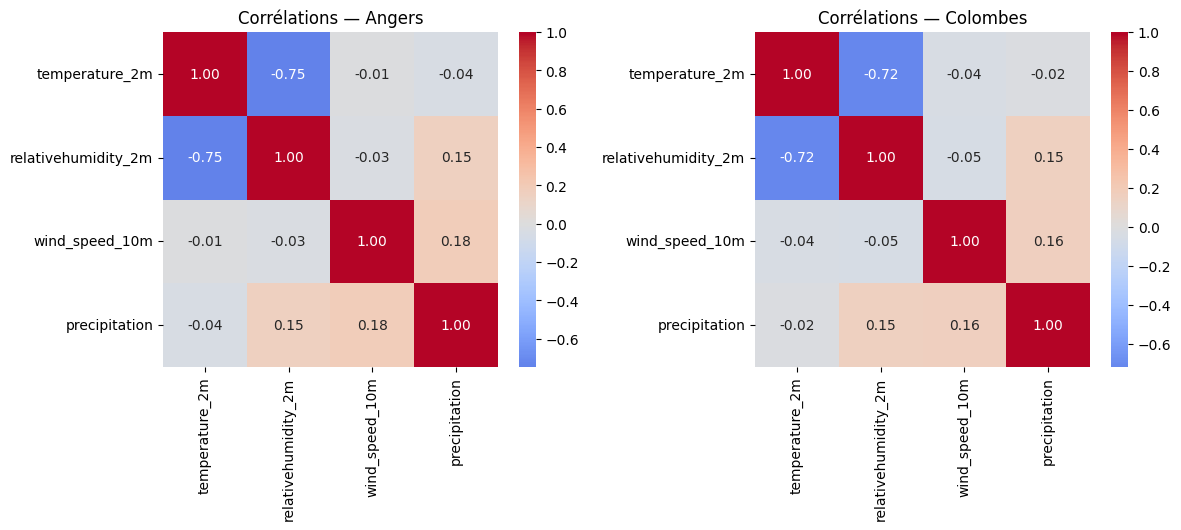

In [ ]:
# Heatmap corrélations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ville in zip(axes, ['Angers', 'Colombes']):
    corr = df_meteo[df_meteo['ville'] == ville][['temperature_2m', 'relativehumidity_2m', 'wind_speed_10m', 'precipitation']].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, center=0, square=True)
    ax.set_title(f'Corrélations — {ville}')
plt.tight_layout()
plt.show()

---
## 4 — Éducation

In [ ]:
df_edu.groupby('Nom_commune')['Type_etablissement'].value_counts()

Nom_commune  Type_etablissement        
Angers       Ecole                         75
             Collège                       27
             Lycée                         20
             Service Administratif         12
             Médico-social                  8
             Information et orientation     1
Colombes     Ecole                         40
             Collège                        9
             Lycée                          5
             Médico-social                  3
             Service Administratif          2
             Information et orientation     1
Name: count, dtype: int64

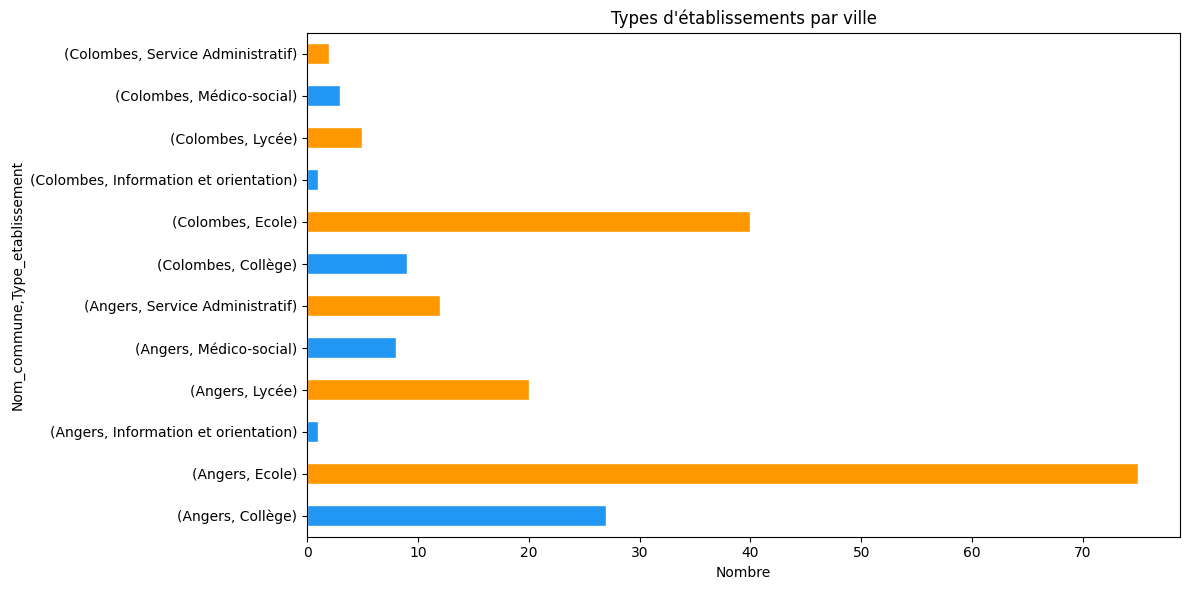

In [38]:
# Types d'établissements
type_counts = df_edu.groupby(['Nom_commune', 'Type_etablissement']).size()
type_counts.T.plot(kind='barh', color=COLORS, figsize=(12, 6), edgecolor='white')
plt.title("Types d'établissements par ville")
plt.xlabel("Nombre")
plt.tight_layout()
plt.show()

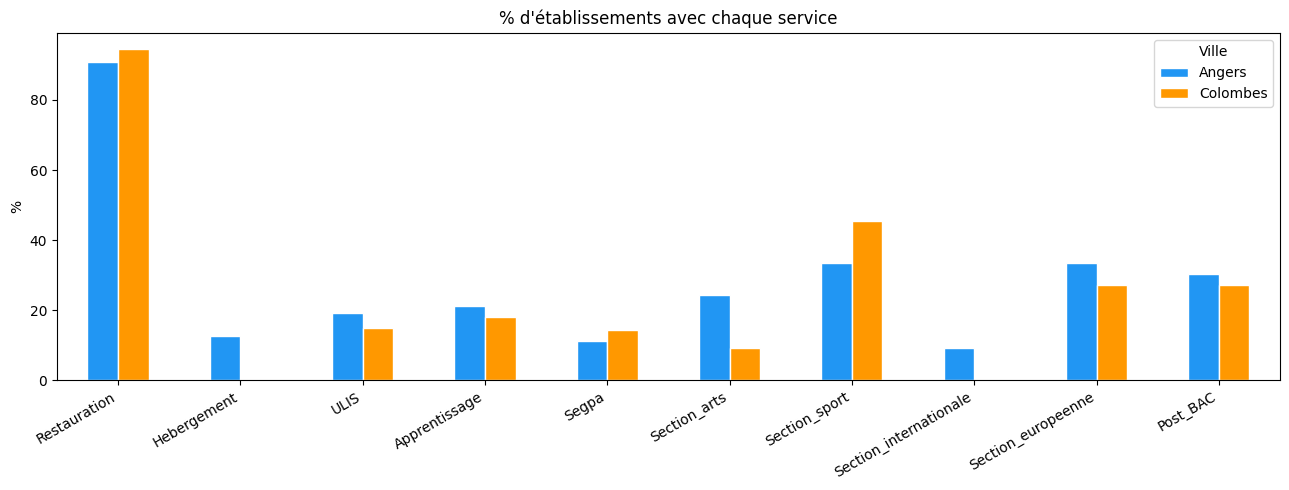

In [37]:
# Taux d'équipement
pcts = df_edu.groupby('Nom_commune')[['Restauration', 'Hebergement', 'ULIS', 'Apprentissage', 'Segpa',
    'Section_arts', 'Section_sport', 'Section_internationale', 'Section_europeenne', 'Post_BAC']].mean() * 100

pcts.T.plot(kind='bar', color=COLORS, figsize=(13, 5), edgecolor='white')
plt.title("% d'établissements avec chaque service")
plt.ylabel('%')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Ville')
plt.tight_layout()
plt.show()

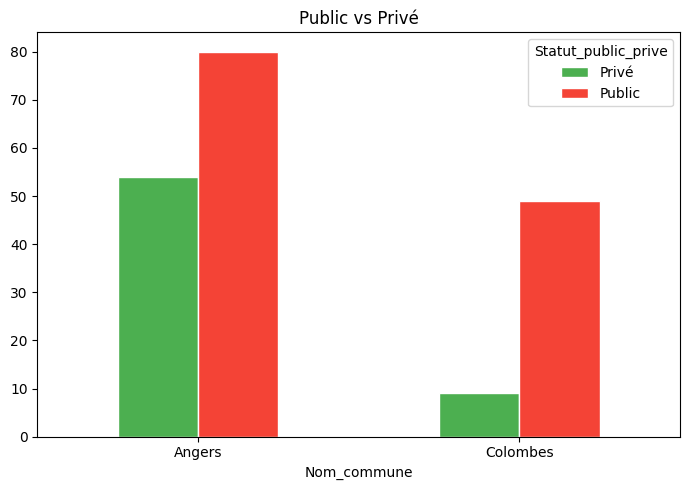

In [39]:
# Public vs Privé
statut = df_edu.groupby(['Nom_commune', 'Statut_public_prive']).size().unstack(fill_value=0)
statut.plot(kind='bar', color=['#4CAF50', '#F44336'], figsize=(7, 5), edgecolor='white')
plt.title('Public vs Privé')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 5 — Culture

In [40]:
df_cult.groupby('libelle_geographique')['Domaine'].value_counts()

libelle_geographique  Domaine               
Angers                Patrimoine                113
                      Livre et presse            43
                      Lecture publique            9
                      Archives                    5
                      Arts du spectacle           5
                      Cinéma                      2
                      Éducation et formation      1
Colombes              Livre et presse            12
                      Patrimoine                  5
                      Lecture publique            3
                      Arts du spectacle           2
                      Cinéma                      2
                      Archives                    1
                      Éducation et formation      1
Name: count, dtype: int64

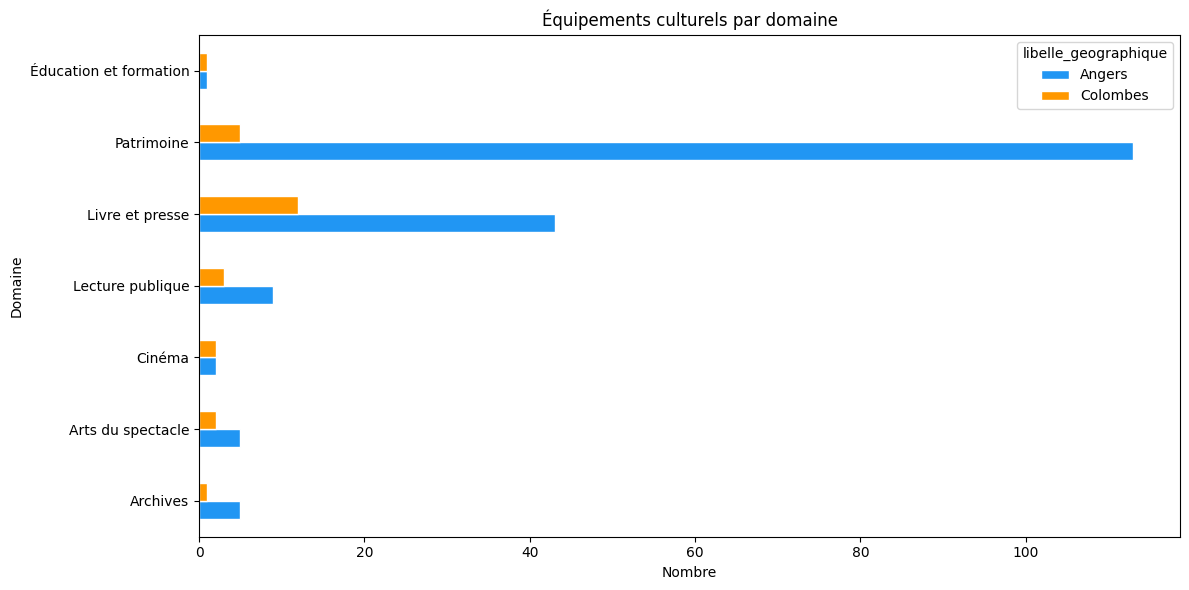

In [41]:
# Par domaine
dom = df_cult.groupby(['libelle_geographique', 'Domaine']).size().unstack(fill_value=0)
dom.T.plot(kind='barh', color=COLORS, figsize=(12, 6), edgecolor='white')
plt.title('Équipements culturels par domaine')
plt.xlabel('Nombre')
plt.tight_layout()
plt.show()

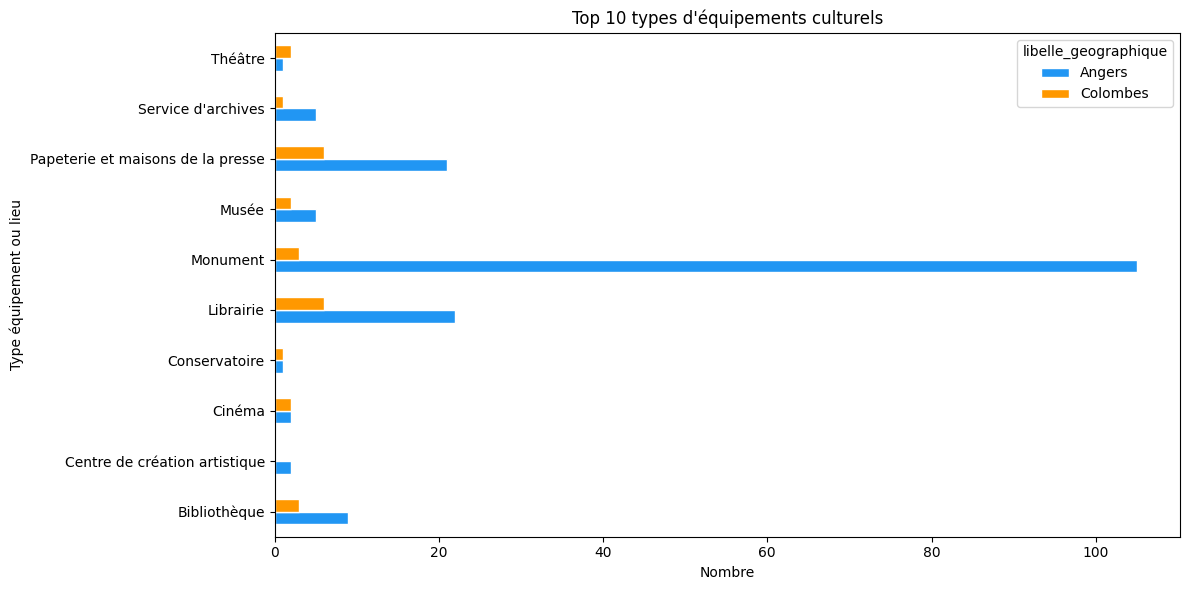

In [42]:
# Par type d'équipement
top_types = df_cult['Type équipement ou lieu'].value_counts().head(10).index
type_counts = df_cult[df_cult['Type équipement ou lieu'].isin(top_types)].groupby(['libelle_geographique', 'Type équipement ou lieu']).size().unstack(fill_value=0)
type_counts.T.plot(kind='barh', color=COLORS, figsize=(12, 6), edgecolor='white')
plt.title("Top 10 types d'équipements culturels")
plt.xlabel('Nombre')
plt.tight_layout()
plt.show()

---
## 6 — Sport

In [43]:
df_sport.groupby('Commune nom')["Type d'équipement sportif"].value_counts()

Commune nom  Type d'équipement sportif    
Angers       Court de tennis                  56
             Multisports/City-stades          54
             Salle multisports (gymnase)      45
             Terrain de football              43
             Terrain de basket-ball           38
                                              ..
Colombes     Salle d'escrime                   1
             Salle de boxe                     1
             Salle de cours collectifs         1
             Terrain de baseball /softball     1
             Terrain mixte                     1
Name: count, Length: 98, dtype: int64

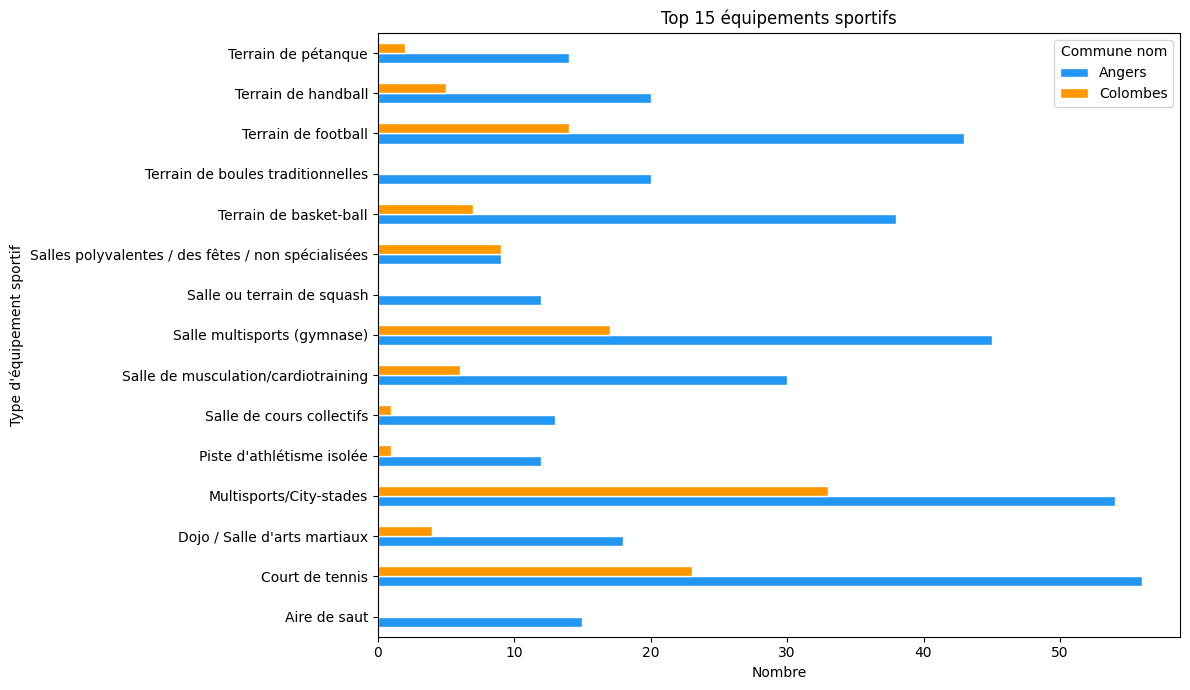

In [44]:
# Top 15 équipements sportifs
top15 = df_sport["Type d'équipement sportif"].value_counts().head(15).index
sport_top = df_sport[df_sport["Type d'équipement sportif"].isin(top15)].groupby(['Commune nom', "Type d'équipement sportif"]).size().unstack(fill_value=0)
sport_top.T.plot(kind='barh', color=COLORS, figsize=(12, 7), edgecolor='white')
plt.title("Top 15 équipements sportifs")
plt.xlabel('Nombre')
plt.tight_layout()
plt.show()

---
## 7 — Emploi et Entreprises

In [49]:
print('Lignes par ville :')
df_emp['ville'].value_counts()


Lignes par ville :


ville
Angers      5970
Colombes     247
Name: count, dtype: int64

In [ ]:

display(df_emp.groupby('ville')["Grand secteur d'activité"].value_counts())

ville     Grand secteur d'activité                  
Angers    GS5 Autres services marchands hors intérim    2050
          GS3 Commerce                                  1341
          GS1 Industrie                                  924
          GS2 Construction                               763
          GS7 Services non marchands                     589
          GS4 Hôtellerie-restauration                    286
          GS6 Intérim                                     17
Colombes  GS5 Autres services marchands hors intérim     108
          GS3 Commerce                                    69
          GS7 Services non marchands                      22
          GS1 Industrie                                   21
          GS2 Construction                                19
          GS4 Hôtellerie-restauration                      7
          GS6 Intérim                                      1
Name: count, dtype: int64

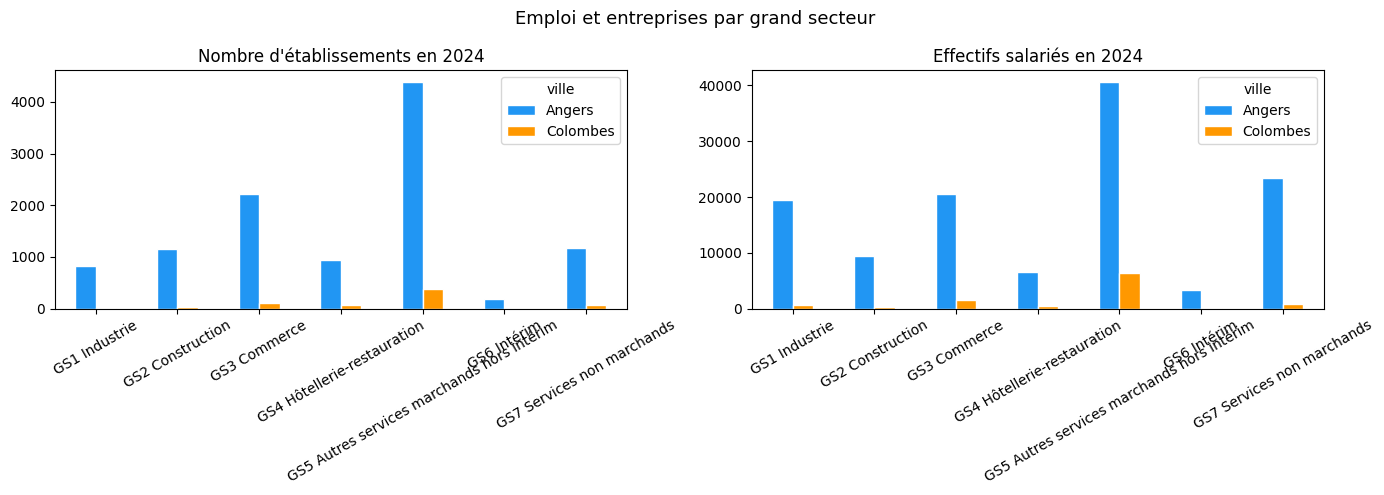

In [51]:
# Nombre d'établissements et effectifs salariés en 2024 par secteur
by_sector = df_emp.groupby(['ville', "Grand secteur d'activité"]).agg(
    nb_etablissements=("Nombre d'établissements 2024", 'sum'),
    effectifs=("Effectifs salariés 2024", 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nb établissements
pivot_etab = by_sector.pivot(index="Grand secteur d'activité", columns='ville', values='nb_etablissements').fillna(0)
pivot_etab.plot(kind='bar', color=COLORS, ax=axes[0], edgecolor='white')
axes[0].set_title("Nombre d'établissements en 2024")
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Effectifs
pivot_eff = by_sector.pivot(index="Grand secteur d'activité", columns='ville', values='effectifs').fillna(0)
pivot_eff.plot(kind='bar', color=COLORS, ax=axes[1], edgecolor='white')
axes[1].set_title("Effectifs salariés en 2024")
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Emploi et entreprises par grand secteur', fontsize=13)
plt.tight_layout()
plt.show()

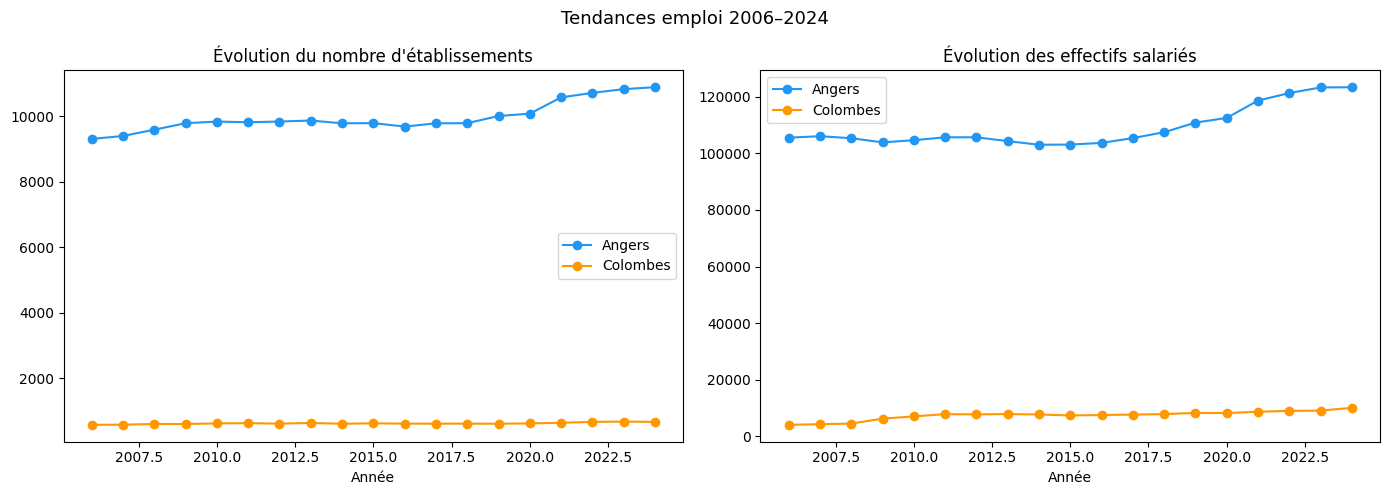

In [52]:
# Evolution des effectifs salariés totaux de 2006 à 2024
annees = list(range(2006, 2025))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ville, color in zip(['Angers', 'Colombes'], COLORS):
    sub = df_emp[df_emp['ville'] == ville]
    total_etab = [sub[f"Nombre d'établissements {a}"].sum() for a in annees]
    total_eff  = [sub[f"Effectifs salariés {a}"].sum() for a in annees]
    axes[0].plot(annees, total_etab, marker='o', label=ville, color=color)
    axes[1].plot(annees, total_eff,  marker='o', label=ville, color=color)

axes[0].set_title("Évolution du nombre d'établissements")
axes[0].set_xlabel('Année')
axes[0].legend()

axes[1].set_title('Évolution des effectifs salariés')
axes[1].set_xlabel('Année')
axes[1].legend()

plt.suptitle('Tendances emploi 2006–2024', fontsize=13)
plt.tight_layout()
plt.show()

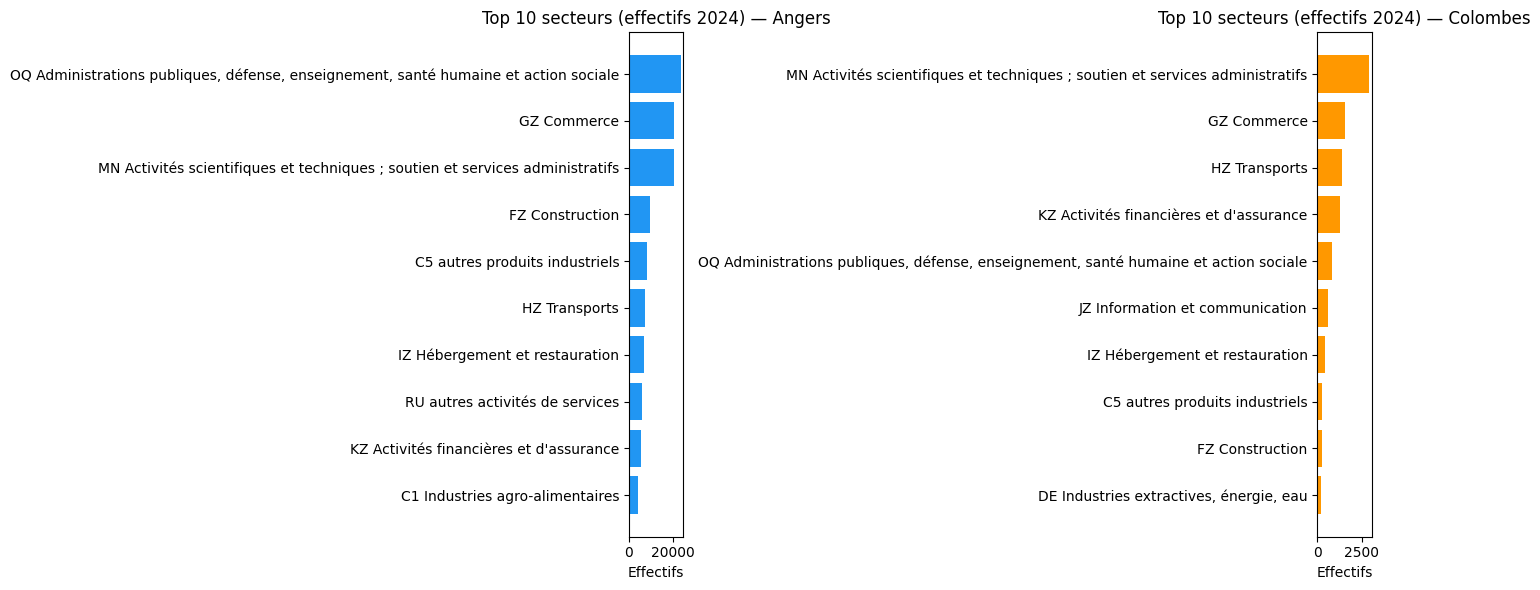

In [53]:
# Top 10 secteurs NA17 par effectifs en 2024
top_secteurs = df_emp.groupby(['ville', 'Secteur NA17'])["Effectifs salariés 2024"].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, ville, color in zip(axes, ['Angers', 'Colombes'], COLORS):
    sub = top_secteurs[top_secteurs['ville'] == ville].nlargest(10, "Effectifs salariés 2024")
    ax.barh(sub['Secteur NA17'], sub["Effectifs salariés 2024"], color=color)
    ax.set_title(f'Top 10 secteurs (effectifs 2024) — {ville}')
    ax.set_xlabel('Effectifs')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [54]:
df_emp.groupby('ville')[["Nombre d'établissements 2024", "Effectifs salariés 2024"]].describe()

Nombre d'établissements 2024                                          \
                                count      mean       std  min  25%  50%  75%   
ville                                                                           
Angers                         3810.0  2.859055  8.348747  1.0  1.0  1.0  2.0   
Colombes                        161.0  4.180124  7.453093  1.0  1.0  2.0  4.0   

                Effectifs salariés 2024                                   \
            max                   count       mean         std  min  25%   
ville                                                                      
Angers    198.0                  3809.0  32.386978  113.347422  0.0  2.0   
Colombes   67.0                   161.0  62.732919  172.043191  1.0  3.0   

                              
           50%   75%     max  
ville                         
Angers     6.0  21.0  2671.0  
Colombes  10.0  39.0  1434.0